In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
from netCDF4 import Dataset
import seaborn as sns
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import numpy.ma as ma
from scipy import signal
from scipy import stats
import matplotlib.patches as mpatches
import random
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker

import function_AH_NAO_copy as f

In [2]:
bounds = {
    "North Atlantic": (0, 70, -90, 10, 'NA'),
    "Azores High": (10, 52, -60, 10, 'AH'),
    "Iceland Low": (40, 75, -90, 20, 'IL')}
min_thresh = 0.2
max_thresh = 0.8
season = 'all'

In [3]:
#import data
#whaling
whaling_xr = xr.open_dataset('/data0/neele.sander/tier4whaler_uvwind_2026-03-19_xr.nc')
whaling_xr = f.lon180(whaling_xr)
whaling_xr = whaling_xr.sel(time = slice('1820','1900'))
NA_whaling = whaling_xr.sel(lon=slice(*bounds["North Atlantic"][2:4]), lat=slice(*bounds["North Atlantic"][0:2]))
NA_whaling = xr.where((NA_whaling['lon']<-70) & (NA_whaling['lat']<10), np.nan,NA_whaling)
#20CR pressure
pathpres = '/data0/neele.sander/20c_reanalysis.nc'
data = xr.open_dataset(pathpres)
#20CR speed
dsu = xr.open_dataset('/data0/neele.sander/uwnd.10m.mon.mean.nc')
dsv = xr.open_dataset('/data0/neele.sander/vwnd.10m.mon.mean.nc')
latmin, latmax ,lonmin, lonmax = bounds["North Atlantic"][0:4]
data_model = f.open_model(dsu, dsv, latmin, latmax ,lonmin, lonmax)

# Adjust wind components
data_model = f.adjust_wind_components(data_model)

In [4]:
# Azores High Index
AH, IL, NA = f.up(data, season, True, bounds)
AH_series_all = f.std_season_sort(AH, AH, 1)
AH_series_t_all = AH_series_all.sel(time=slice(np.min(NA_whaling.time), '1900-12-31T12:00:00.000000000'))
NA_t = NA.sel(time=slice(np.min(whaling_xr.time) , '1900-12-31T12:00:00.000000000'))
AHA_qm_all, AHA_q_all, AHA_great_events_roll_all, AH_mask_big_all = f.amount_mask_quantile(min_thresh, max_thresh, AH_series_t_all, 25, 'big')

#select especially big and small events
mask_big = xr.where(AH_series_t_all['prmsl'] >= AHA_q_all, AH_series_t_all, np.nan)
mask_small = xr.where(AH_series_t_all['prmsl'] <= AHA_qm_all, AH_series_t_all, np.nan)
amount_big = mask_big.groupby('time.year').count().rolling(year = 1, center = False).sum()
amount_small = mask_small.groupby('time.year').count().rolling(year = 1, center = False).sum()

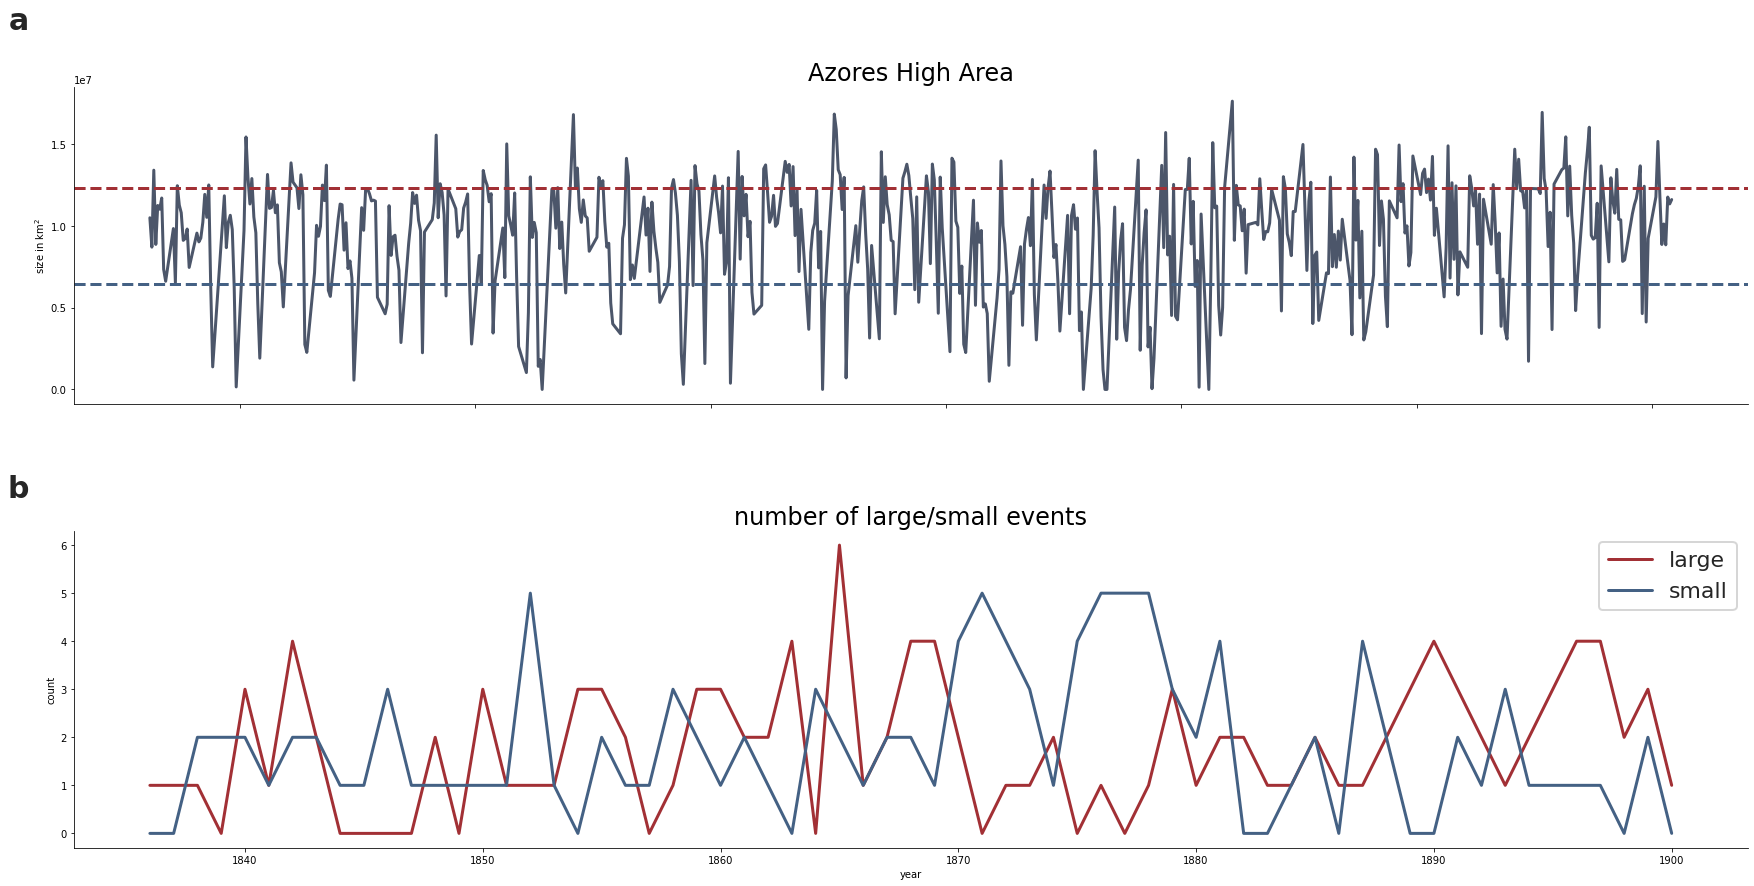

In [5]:
fig, (ax1,ax2) = plt.subplots(2,1, figsize = (30,14))
sns.set(style = 'whitegrid', context = 'poster', font_scale=1)
sns.lineplot(data=AH_series_t_all, x='time', y='prmsl', ax = ax1,color='#4C566A') 
ax1.axhline(y=AHA_qm_all, color='#446184', linestyle='--',lw='3')
ax1.axhline(y=AHA_q_all, color='#A23035', linestyle='--',lw='3')
ax1.text(np.datetime64('1830-03-01T00:00:00.000000000'),2.2e7, 'a', weight = 'bold', size = 30)
ax1.set_title('Azores High Area')
amount_big['prmsl'].plot(ax=ax2, label='large',color='#A23035')
amount_small['prmsl'].plot(ax=ax2, label='small', color='#446184')
legend = ax2.legend()
frame = legend.get_frame()
ax1.set(ylabel='size in km$^2$',xlabel=None)
ax1.set_xticklabels([])
ax2.set(ylabel='count')
ax2.text(1830,7, 'b', weight = 'bold', size = 30)
ax2.set_title('number of large/small events')
plt.subplots_adjust(hspace=0.4)
sns.despine(top=True)
plt.savefig('plots/paper/AHindex.png', dpi=300)
plt.show()

In [6]:
#times need to fit --> no winter
NA_t = NA_t.isel(time = NA_t.time.dt.month.isin([3,4,5,6,7,8,9,10,11]))
#determine extremely big and small events
AH_exbig = f.extreme(AH_series_t_all, AH_series_t_all, NA_t, 'big', 'big',min_thresh, max_thresh)
AH_exsmall = f.extreme(AH_series_t_all, AH_series_t_all, NA_t, 'small', 'small',min_thresh, max_thresh)

In [7]:
# Categorize AH series
AH_big = f.categorize_ah_series(AH_series_t_all, AH_exbig, AH_exsmall)

# Resample AH data
AH_big_d = AH_big.resample(time='D').nearest(tolerance="30D")

# Filter data by category
big_AH_d = f.filter_by_category(AH_big_d, 10)
small_AH = f.filter_by_category(AH_big_d, -10)
neut_AH = f.filter_by_category(AH_big_d, 0)

In [8]:
#deal with NAO
NAO = np.loadtxt('/home/neele.sander/Downloads/nao.20crv3.long.data.txt', skiprows = 1, max_rows=180)
winter = False
NAOpos, NAOneg, NAOneut = f.process_nao(NAO, whaling_xr, winter)

In [9]:
##### sort data by happening
#sort whaling data
NA_whaling_NAOp = xr.where(NA_whaling.time.dt.date.isin(NAOpos.time.dt.date), NA_whaling, np.nan)
NA_whaling_NAOn = xr.where(NA_whaling.time.dt.date.isin(NAOneg.time.dt.date), NA_whaling, np.nan)
NA_whaling_NAOneut = xr.where(NA_whaling.time.dt.date.isin(NAOneut.time.dt.date), NA_whaling, np.nan)

# Extract whaling data based on AH categories
NA_whaling_big_AH = f.get_whaling_data(NA_whaling, big_AH_d)
NA_whaling_small_AH = f.get_whaling_data(NA_whaling, small_AH)
NA_whaling_neut_AH = f.get_whaling_data(NA_whaling, neut_AH)

#sort model data
data_model_NAOp = xr.where(data_model.time.dt.date.isin(NAOpos.time.dt.date), data_model, np.nan).dropna('time','all')
data_model_NAOn = xr.where(data_model.time.dt.date.isin(NAOneg.time.dt.date), data_model, np.nan).dropna('time','all')
data_model_NAOneut = xr.where(data_model.time.dt.date.isin(NAOneut.time.dt.date), data_model, np.nan).dropna('time','all')

# Extract model data based on AH categories
NA_model_big_AH = f.get_whaling_data(data_model, big_AH_d)
NA_model_small_AH = f.get_whaling_data(data_model, small_AH)
NA_model_neut_AH = f.get_whaling_data(data_model, neut_AH)

In [10]:
#backgroundshading
smallminneut = np.fabs(NA_model_small_AH['speed'].mean('time'))-np.fabs(data_model['speed'].mean('time'))
bigminneut = np.fabs(NA_model_big_AH['speed'].mean('time'))-np.fabs(data_model['speed'].mean('time'))
negminneut = np.fabs(data_model_NAOn['speed'].mean('time'))-np.fabs(data_model['speed'].mean('time'))
posminneut = np.fabs(data_model_NAOp['speed'].mean('time'))-np.fabs(data_model['speed'].mean('time'))

In [11]:
data_model_zonal = data_model['uwndB'].mean(['lon'])


In [12]:
AH_small_quans, AH_small_quanb, distr_AH_small = f.MC_bootstrap(NA_model_small_AH['uwndB'], data_model_zonal, 1000, False)
AH_big_quans, AH_big_quanb, distr_AH_big = f.MC_bootstrap(NA_model_big_AH['uwndB'], data_model_zonal, 1000, False)
NAOp_quans, NAOp_quanb, distr_NAOp = f.MC_bootstrap(data_model_NAOp['uwndB'], data_model_zonal, 1000, False)
NAOn_quans, NAOn_quanb, distr_NAOn = f.MC_bootstrap(data_model_NAOn['uwndB'], data_model_zonal, 1000,False)

In [13]:
levels = np.arange(-1.3,1.35,0.05)
binstep = 3
bins = int((latmax - latmin)/binstep)

In [14]:
#stop

NameError: name 'stop' is not defined

/tmp/ipykernel_42977/3873122774.py:48: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(right=0.835)
/tmp/ipykernel_42977/3873122774.py:50: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")


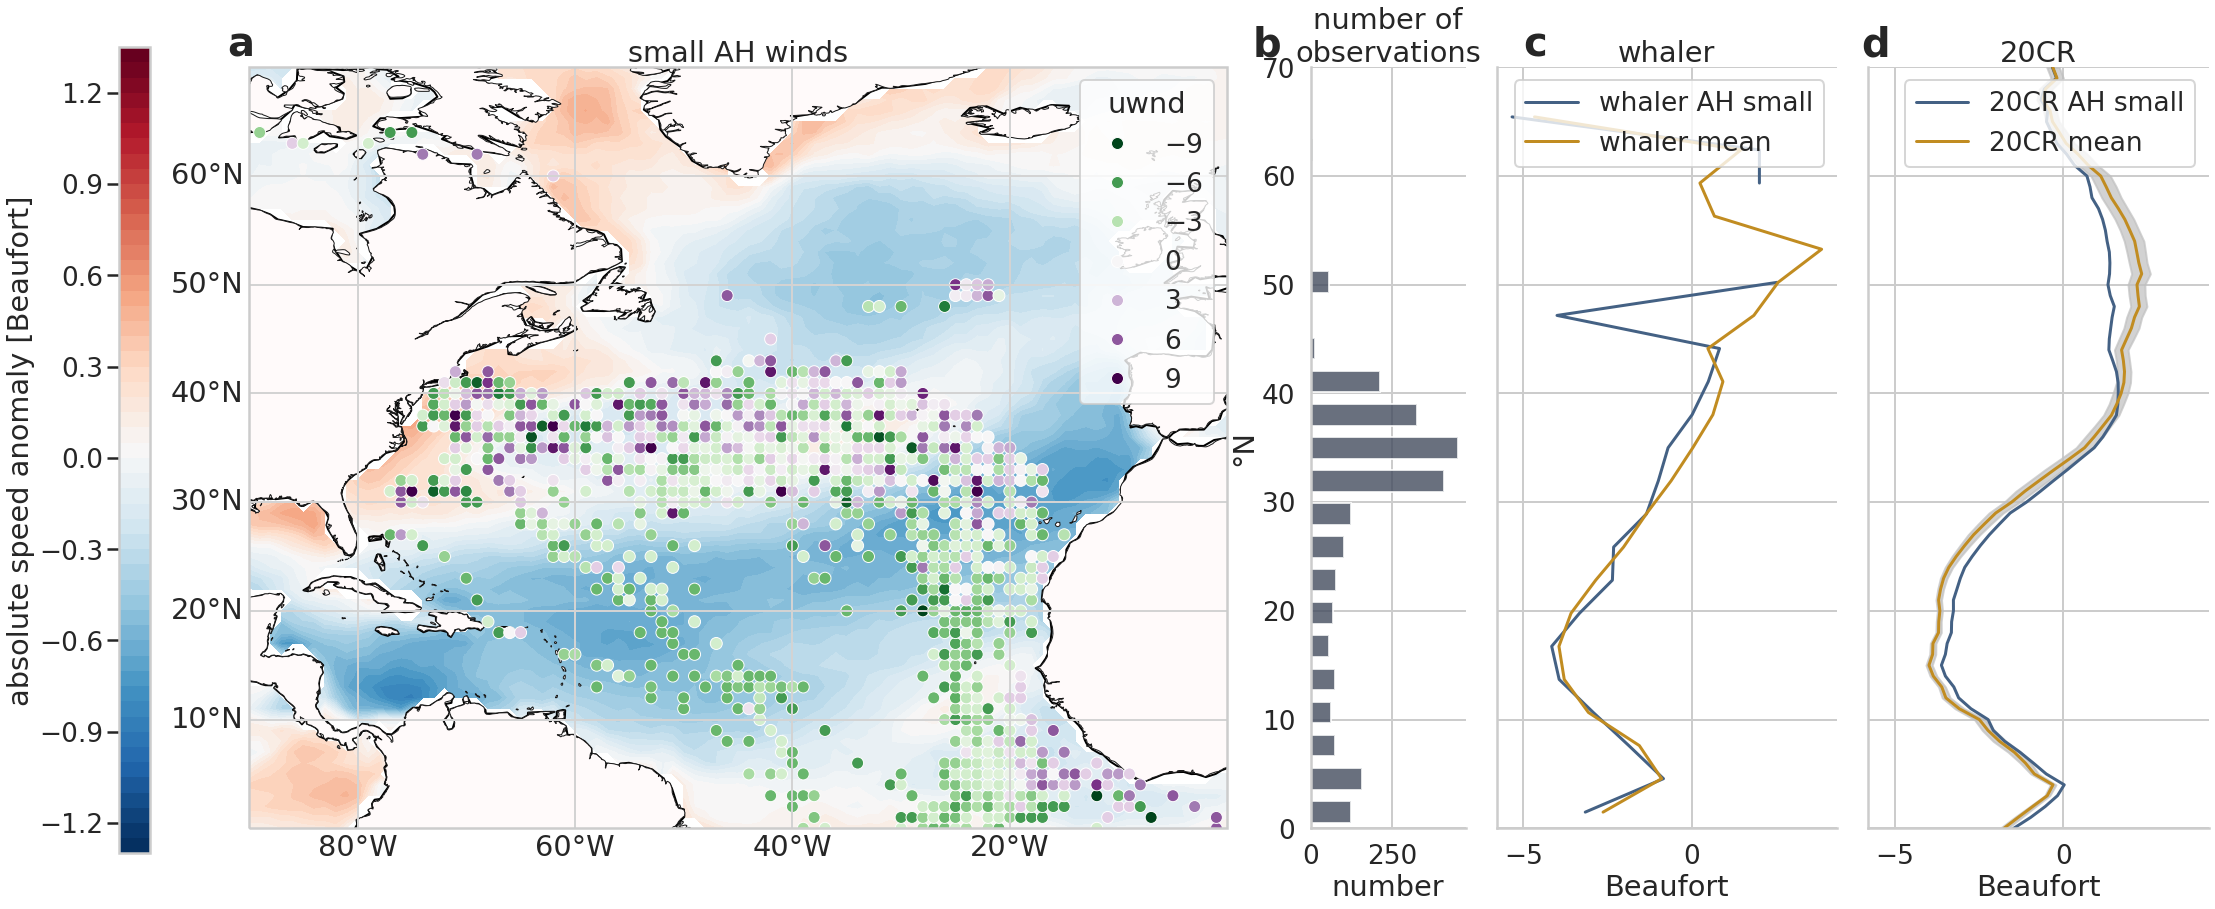

In [15]:
#plt.rcParams['font.size'] = 12
AH_small_df = NA_whaling_small_AH['uwnd'].mean('time').to_dataframe().reset_index().dropna()

sns.set(style='whitegrid', context='poster', font_scale=1.2)
fig = plt.figure(figsize=(43, 14), constrained_layout=True)
gs = GridSpec(4, 12, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:6], projection=ccrs.PlateCarree())
ax05 = fig.add_subplot(gs[:, 6:7])
ax1 = fig.add_subplot(gs[:, 7:9])
ax2 = fig.add_subplot(gs[:, 9:11], sharex=ax1)

#whaling data
NA_whaling_small_AH_bin = NA_whaling_small_AH['uwnd'].count(['time','lon']).groupby_bins('lat',bins).sum().to_dataframe().reset_index().dropna()
NA_whaling_small_AH_bin['lat_bin'] = NA_whaling_small_AH_bin['index'].apply(lambda x: x.mid)

NA_whaling_small_AH['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler AH small'
                                                                                    ,color='#446184', ax=ax1)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax1,color='#C18C21')

#20CR data
NA_model_small_AH['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#446184', label ='20CR AH small')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(AH_small_quans.lat.values,AH_small_quans.values, AH_small_quanb.values, color='silver', alpha=0.7 )

ax05.set(ylabel='°N', xlabel='number')
ax05.set_title('number of\nobservations')
ax05.text(-180,71, 'b', weight = 'bold', size = 40)
ax1.set_title('whaler')
ax1.text(-5,71, 'c', weight = 'bold', size = 40)
ax2.set_title('20CR')
ax2.text(-6,71, 'd', weight = 'bold', size = 40)

ax05.barh(NA_whaling_small_AH_bin['lat_bin'], NA_whaling_small_AH_bin['uwnd'],color='#434C5E', height =2, alpha=0.8)
sns.despine(ax=ax05)
im = smallminneut.plot.contourf(ax=ax0, cmap = 'RdBu_r',add_colorbar=False,levels = levels)
ax0.text(-92,71, 'a', weight = 'bold', size = 40)
ax0.coastlines()
ax0.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax0.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax0.set_title('small AH winds')

gl = ax0.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=AH_small_df['lon'],y=AH_small_df['lat'],hue=AH_small_df['uwnd'],palette='PRGn_r', ax=ax0)
fig.subplots_adjust(right=0.835) 
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')


ax0_ylim = ax0.get_ylim()
ax05.set_ylim(ax0_ylim)
for ax_ in [ax1, ax2]:
    ax_.set_ylim(ax0_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)

plt.savefig('plots/paper/AHsmall.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/tmp/ipykernel_42977/768363951.py:47: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(right=0.835)
/tmp/ipykernel_42977/768363951.py:49: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")


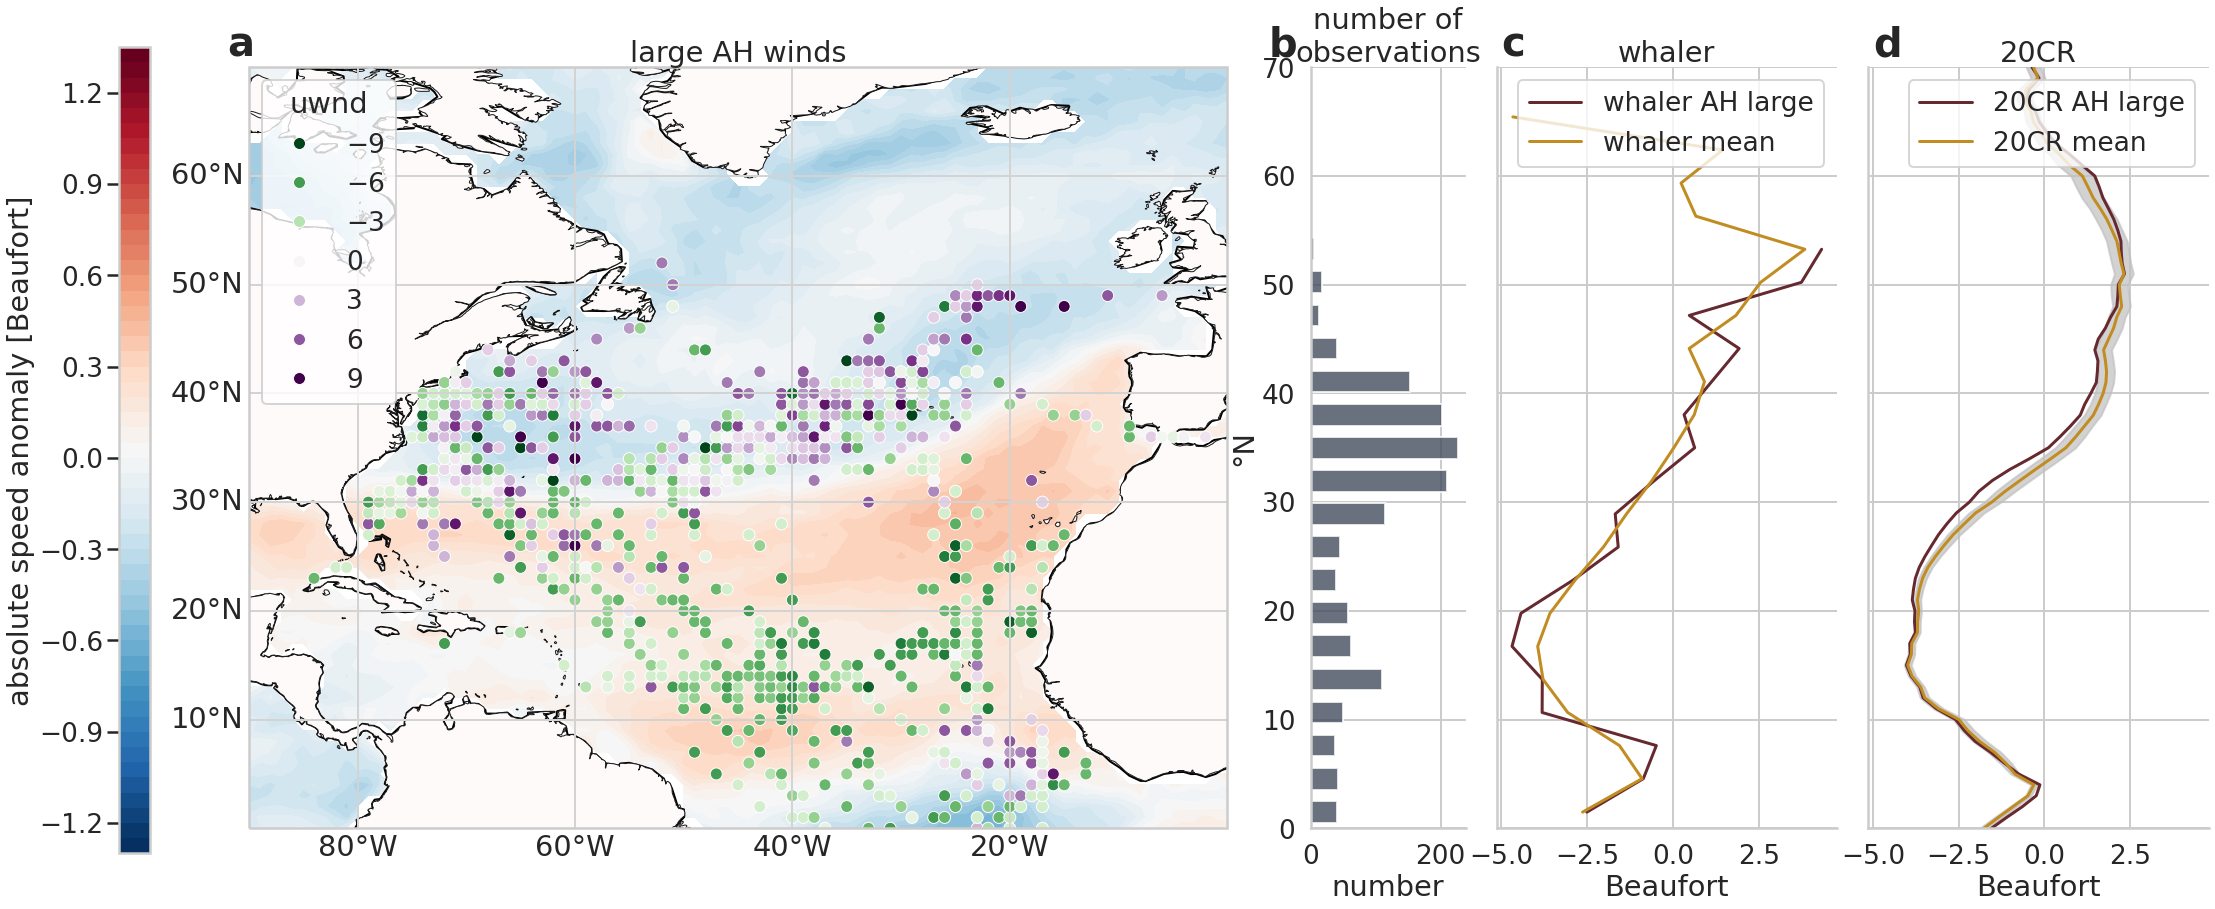

In [16]:
AH_big_df = NA_whaling_big_AH['uwnd'].mean('time').to_dataframe().reset_index().dropna()

fig = plt.figure(figsize=(43, 14), constrained_layout=True)
gs = GridSpec(4, 12, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:6], projection=ccrs.PlateCarree())
ax05 = fig.add_subplot(gs[:, 6:7])
ax1 = fig.add_subplot(gs[:, 7:9])
ax2 = fig.add_subplot(gs[:, 9:11], sharex=ax1)

NA_whaling_big_AH_bin = NA_whaling_big_AH['uwnd'].count(['time','lon']).groupby_bins('lat',bins).sum().to_dataframe().reset_index().dropna()
NA_whaling_big_AH_bin['lat_bin'] = NA_whaling_big_AH_bin['index'].apply(lambda x: x.mid)

sns.set(style='whitegrid', context='poster', font_scale=1.2)

NA_model_big_AHv = NA_model_big_AH['uwndB'].mean(['lon']).to_dataframe().reset_index()
NA_model_neut_AHv = NA_model_neut_AH['uwndB'].mean(['lon']).to_dataframe().reset_index()
NA_model_big_AH['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#65292F', label ='20CR AH large')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(AH_big_quans.lat.values,AH_big_quans.values, AH_big_quanb.values, color='silver', alpha=0.7 )


NA_whaling_big_AH['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler AH large',color='#65292F', ax=ax1)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax1,color='#C18C21')
ax05.set(ylabel='°N', xlabel='number')
ax05.set_title('number of\nobservations')
ax05.text(-65,71, 'b', weight = 'bold', size = 40)
ax1.set_title('whaler')
ax1.text(-5,71, 'c', weight = 'bold', size = 40)
ax2.set_title('20CR')
ax2.text(-5,71, 'd', weight = 'bold', size = 40)

ax05.barh(NA_whaling_big_AH_bin['lat_bin'], NA_whaling_big_AH_bin['uwnd'],color='#434C5E', height =2, alpha=0.8)
sns.despine(ax=ax05)
im = bigminneut.plot.contourf(ax=ax0, cmap = 'RdBu_r',add_colorbar=False,levels = levels)
ax0.text(-92,71, 'a', weight = 'bold', size = 40)
ax0.coastlines()
ax0.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax0.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax0.set_title('large AH winds')

gl = ax0.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=AH_big_df['lon'],y=AH_big_df['lat'],hue=AH_big_df['uwnd'],palette='PRGn_r', ax=ax0)
fig.subplots_adjust(right=0.835) 
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

ax0_ylim = ax0.get_ylim()
ax05.set_ylim(ax0_ylim)
for ax_ in [ax1, ax2]:
    ax_.set_ylim(ax0_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)

plt.savefig('plots/paper/AHlarge.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/tmp/ipykernel_42977/2643293111.py:50: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(right=0.835)
/tmp/ipykernel_42977/2643293111.py:52: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")


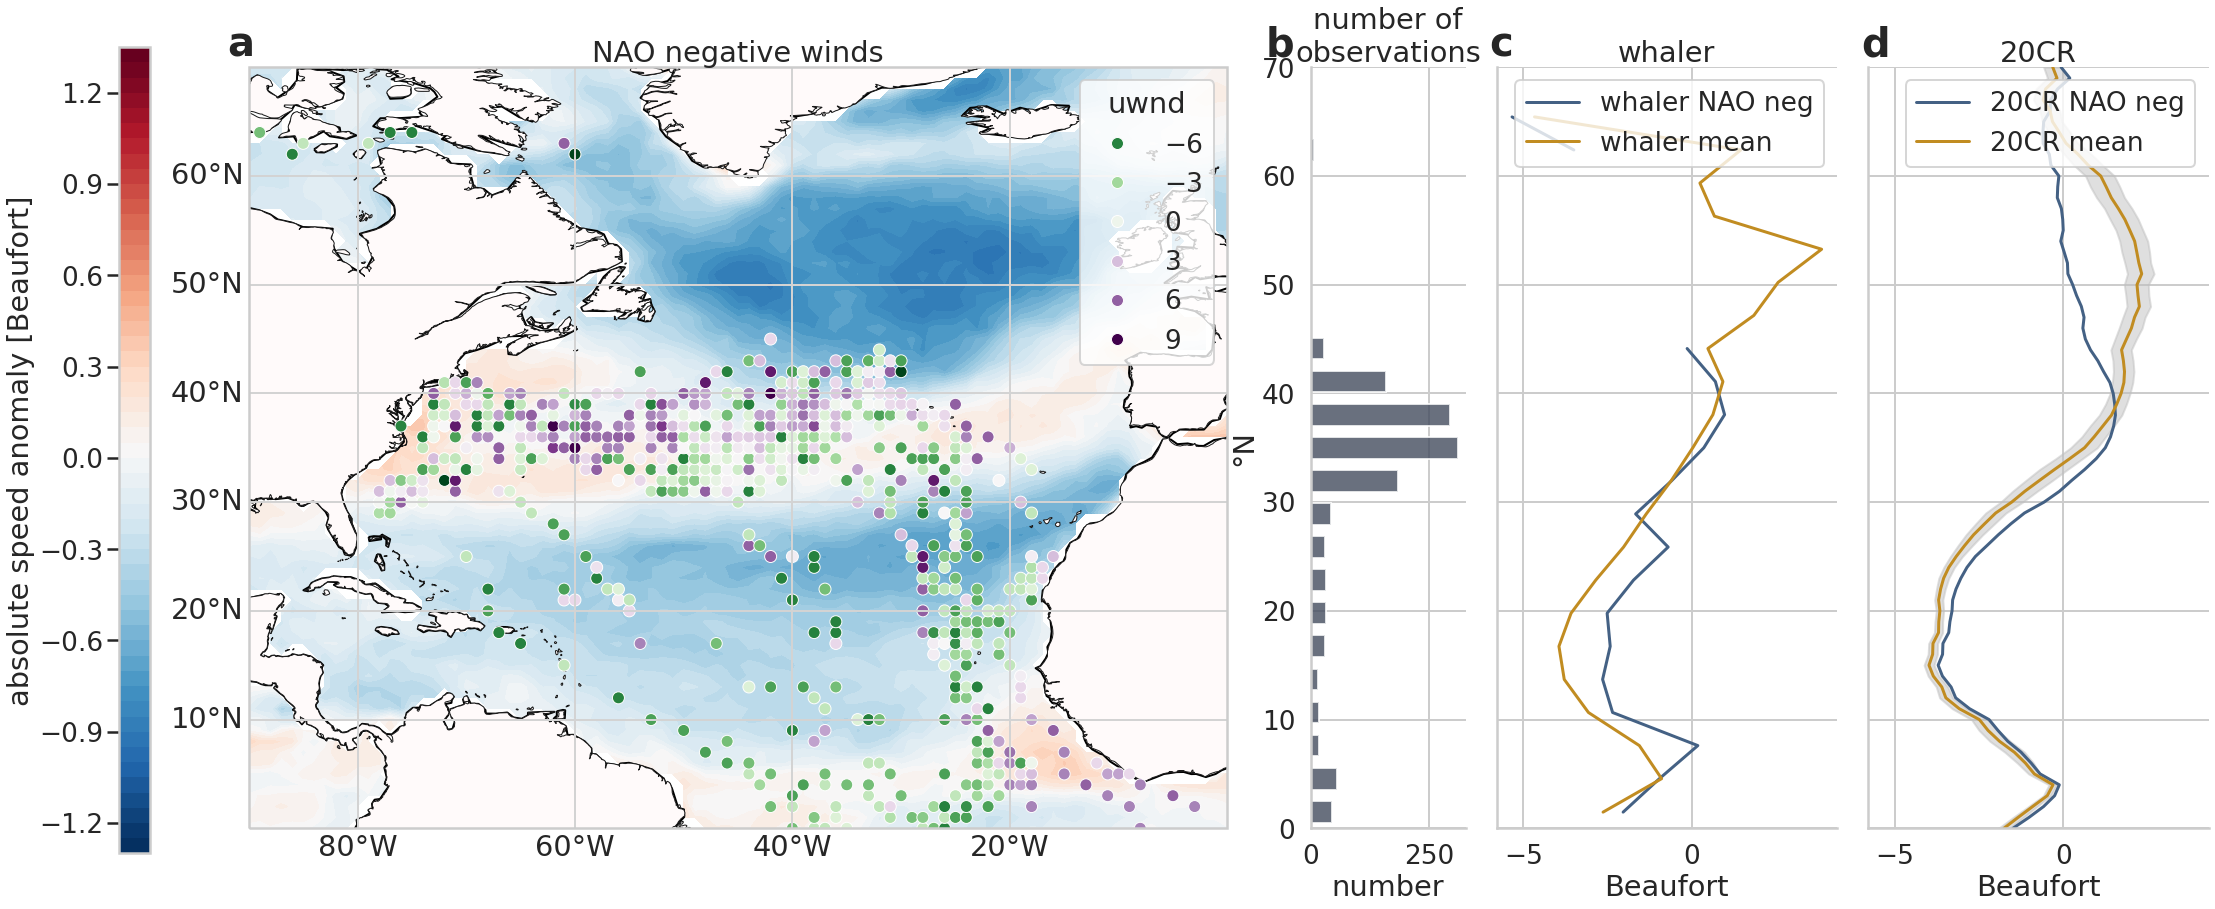

In [17]:
df_NAO_neg = NA_whaling_NAOn['uwnd'].mean('time').to_dataframe().reset_index().dropna()

sns.set(style='whitegrid', context='poster', font_scale=1.2)
fig = plt.figure(figsize=(43, 14), constrained_layout=True) 
gs = GridSpec(4, 12, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:6], projection=ccrs.PlateCarree())
ax05 = fig.add_subplot(gs[:, 6:7])
ax1 = fig.add_subplot(gs[:, 7:9])
ax2 = fig.add_subplot(gs[:, 9:11], sharex=ax1)

NA_whaling_NAOn_bin = NA_whaling_NAOn['uwnd'].count(['time','lon']).groupby_bins('lat',bins).sum().to_dataframe().reset_index().dropna()
NA_whaling_NAOn_bin['lat_bin'] = NA_whaling_NAOn_bin['index'].apply(lambda x: x.mid)


data_model_NAOnv = data_model_NAOn['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOneutv = data_model_NAOneut['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOn['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#446184', label ='20CR NAO neg')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(NAOn_quans.lat.values,NAOn_quans.values, NAOn_quanb.values, color='silver', alpha=0.5 )



NA_whaling_NAOn['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler NAO neg',
                                                                                     color='#446184', ax=ax1)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax1,color='#C18C21')
ax05.set(ylabel='°N', xlabel='number')
ax05.set_title('number of\nobservations')
ax05.text(-95,71, 'b', weight = 'bold', size = 40)
ax1.set_title('whaler')
ax1.text(-6,71, 'c', weight = 'bold', size = 40)
ax2.set_title('20CR')
ax2.text(-6,71, 'd', weight = 'bold', size = 40)

ax05.barh(NA_whaling_NAOn_bin['lat_bin'], NA_whaling_NAOn_bin['uwnd'],color='#434C5E', height =2, alpha=0.8)
sns.despine(ax=ax05)

im = negminneut.plot.contourf(ax=ax0, cmap = 'RdBu_r',add_colorbar=False,levels = levels)
ax0.text(-92,71, 'a', weight = 'bold', size = 40)
ax0.coastlines()
ax0.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax0.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax0.set_title('NAO negative winds')

gl = ax0.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=df_NAO_neg['lon'],y=df_NAO_neg['lat'],hue=df_NAO_neg['uwnd'],palette='PRGn_r', ax=ax0)
fig.subplots_adjust(right=0.835)
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

ax0_ylim = ax0.get_ylim()
ax05.set_ylim(ax0_ylim)
for ax_ in [ax1, ax2]:
    ax_.set_ylim(ax0_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)

plt.savefig('plots/paper/NAOneg.png', dpi = 300, bbox_inches = 'tight')

plt.show()

/tmp/ipykernel_42977/709540780.py:47: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(right=0.835)
/tmp/ipykernel_42977/709540780.py:49: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")


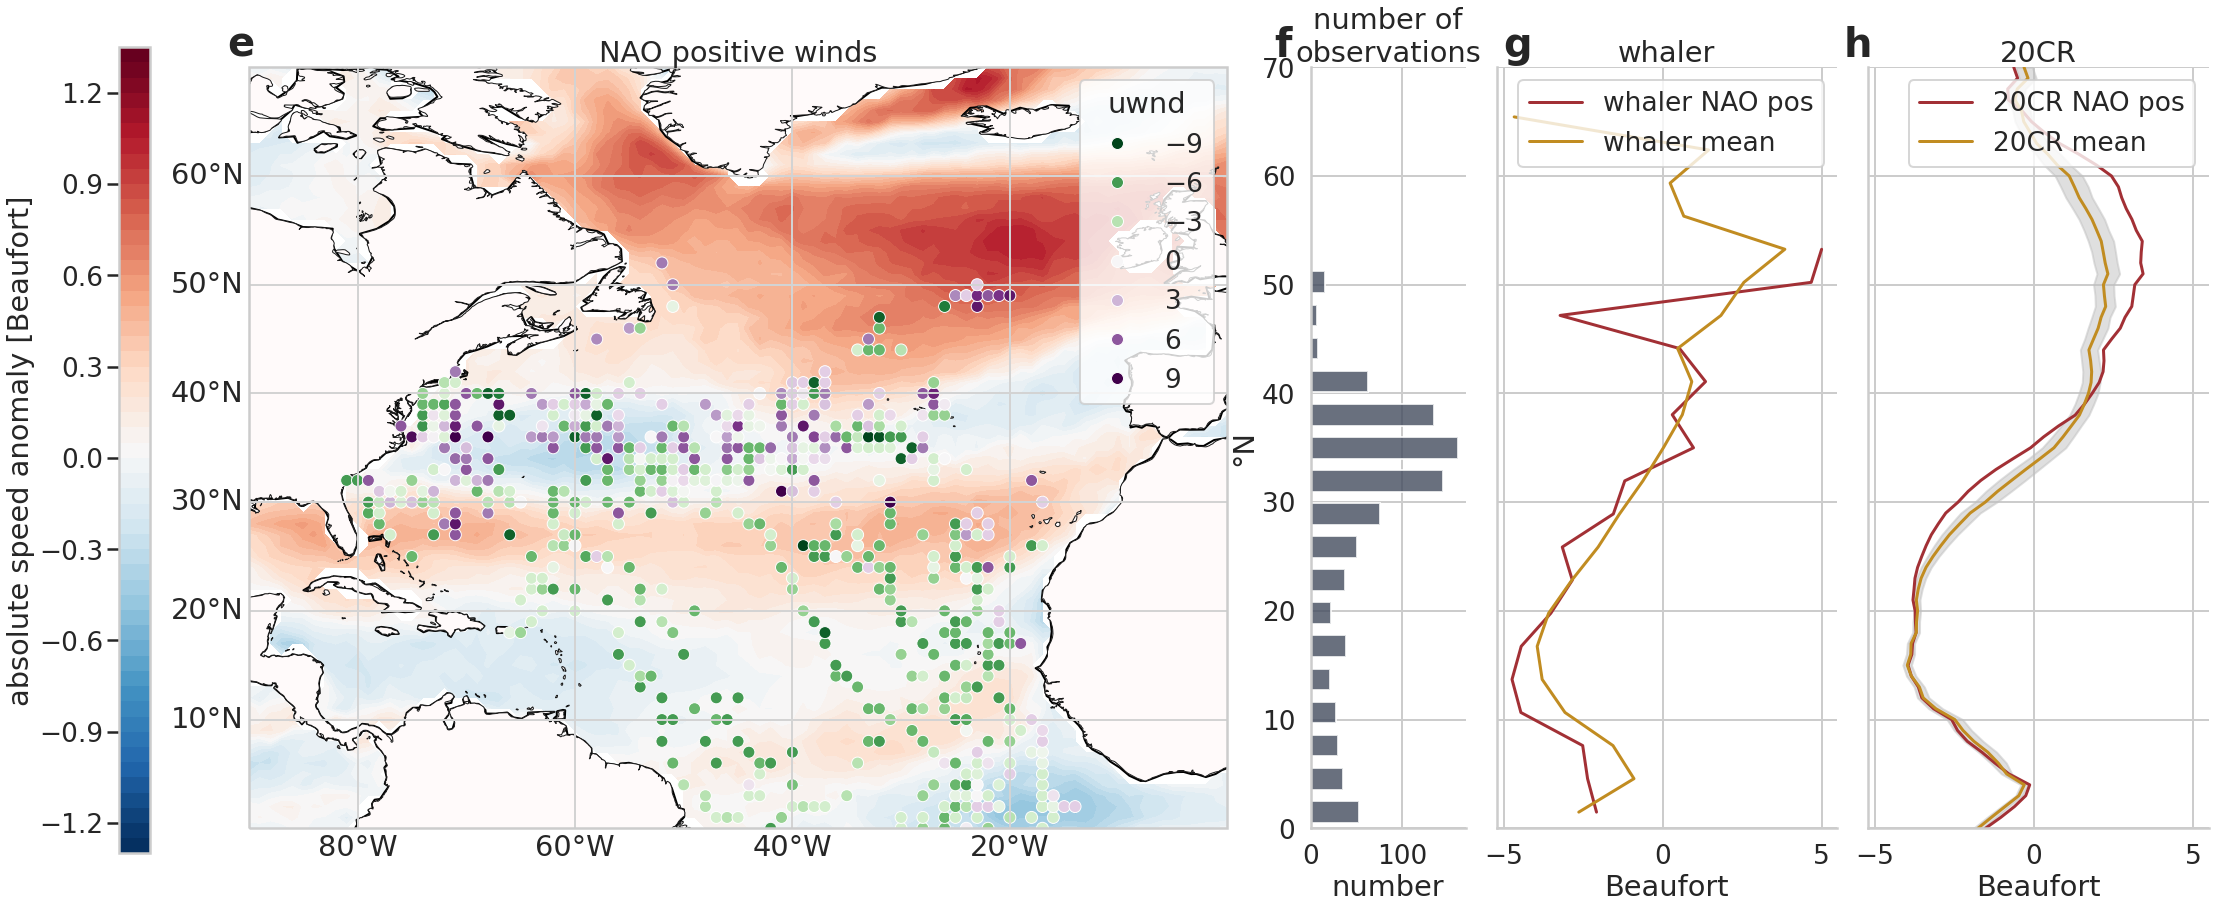

In [18]:
df_NAO_pos = NA_whaling_NAOp['uwnd'].mean('time').to_dataframe().reset_index().dropna()

fig = plt.figure(figsize=(43, 14), constrained_layout=True) 
gs = GridSpec(4, 12, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:6], projection=ccrs.PlateCarree())
ax05 = fig.add_subplot(gs[:, 6:7])
ax1 = fig.add_subplot(gs[:, 7:9])
ax2 = fig.add_subplot(gs[:, 9:11], sharex=ax1)

NA_whaling_NAOp_bin = NA_whaling_NAOp['uwnd'].count(['time','lon']).groupby_bins('lat', bins).sum().to_dataframe().reset_index().dropna()
NA_whaling_NAOp_bin['lat_bin'] = NA_whaling_NAOp_bin['index'].apply(lambda x: x.mid)

sns.set(style='whitegrid', context='poster', font_scale=1.2)
data_model_NAOpv = data_model_NAOp['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOneutv = data_model['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOp['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#A23035', label ='20CR NAO pos')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(NAOp_quans.lat.values,NAOp_quans.values, NAOp_quanb.values, color='silver', alpha=0.5 )


NA_whaling_NAOp['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler NAO pos',color='#A23035', ax=ax1)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax1,color='#C18C21')
ax05.set(ylabel='°N', xlabel='number')
ax05.set_title('number of\nobservations')
ax05.text(-40,71, 'f', weight = 'bold', size = 40)
ax1.set_title('whaler')
ax1.text(-5,71, 'g', weight = 'bold', size = 40)
ax2.set_title('20CR')
ax2.text(-6,71, 'h', weight = 'bold', size = 40)

ax05.barh(NA_whaling_NAOp_bin['lat_bin'], NA_whaling_NAOp_bin['uwnd'],color='#434C5E', height =2,alpha=0.8)
sns.despine(ax=ax05)

im = posminneut.plot.contourf(ax=ax0, cmap = 'RdBu_r',add_colorbar=False, levels = levels)
ax0.text(-92,71, 'e', weight = 'bold', size = 40)
ax0.coastlines()
ax0.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax0.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax0.set_title('NAO positive winds')

gl = ax0.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=df_NAO_pos['lon'],y=df_NAO_pos['lat'],hue=df_NAO_pos['uwnd'],palette='PRGn_r', ax=ax0)
fig.subplots_adjust(right=0.835) 
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8]) #left, bottom, width, height
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

ax0_ylim = ax0.get_ylim()
ax05.set_ylim(ax0_ylim)
for ax_ in [ax1, ax2]:
    ax_.set_ylim(ax0_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)
plt.savefig('plots/paper/NAOpos.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [ ]:
# try to make one plot for caro
# first neg NAO najaaa
df_NAO_neg = NA_whaling_NAOn['uwnd'].mean('time').to_dataframe().reset_index().dropna()

sns.set(style='whitegrid', context='poster', font_scale=1.2)
fig = plt.figure(figsize=(43, 14), constrained_layout=True) 
gs = GridSpec(8, 12, figure=fig)

ax0 = fig.add_subplot(gs[0:4, 0:6], projection=ccrs.PlateCarree())
ax05 = fig.add_subplot(gs[0:4, 6:7])
ax1 = fig.add_subplot(gs[0:4, 7:9])
ax2 = fig.add_subplot(gs[0:4, 9:11], sharex=ax1)

ax3 = fig.add_subplot(gs[4:8, 0:6], projection=ccrs.PlateCarree())
ax35 = fig.add_subplot(gs[4:8, 6:7])
ax4 = fig.add_subplot(gs[4:8, 7:9])
ax5 = fig.add_subplot(gs[4:8, 9:11], sharex=ax1)

NA_whaling_NAOn_bin = NA_whaling_NAOn['uwnd'].count(['time','lon']).groupby_bins('lat',bins).sum().to_dataframe().reset_index().dropna()
NA_whaling_NAOn_bin['lat_bin'] = NA_whaling_NAOn_bin['index'].apply(lambda x: x.mid)


data_model_NAOnv = data_model_NAOn['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOneutv = data_model_NAOneut['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOn['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#446184', label ='20CR NAO neg')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(NAOn_quans.lat.values,NAOn_quans.values, NAOn_quanb.values, color='silver', alpha=0.5 )



NA_whaling_NAOn['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler NAO neg',
                                                                                     color='#446184', ax=ax1)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax1,color='#C18C21')
ax05.set(ylabel='°N', xlabel='number')
ax05.set_title('number of\nobservations')
ax05.text(-85,71, 'b', weight = 'bold', size = 30)
ax1.set_title('whaler')
ax1.text(-6,71, 'c', weight = 'bold', size = 30)
ax2.set_title('20CR')
ax2.text(-6,71, 'd', weight = 'bold', size = 30)

ax05.barh(NA_whaling_NAOn_bin['lat_bin'], NA_whaling_NAOn_bin['uwnd'],color='#434C5E', height =2, alpha=0.8)
sns.despine(ax=ax05)

im = negminneut.plot.contourf(ax=ax0, cmap = 'RdBu_r',add_colorbar=False,levels = levels)
ax0.text(-92,71, 'a', weight = 'bold', size = 30)
ax0.coastlines()
ax0.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax0.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax0.set_title('NAO negative winds')

gl = ax0.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=df_NAO_neg['lon'],y=df_NAO_neg['lat'],hue=df_NAO_neg['uwnd'],palette='PRGn_r', ax=ax0)
fig.subplots_adjust(right=0.835)
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

ax0_ylim = ax0.get_ylim()
ax05.set_ylim(ax0_ylim)
for ax_ in [ax1, ax2]:
    ax_.set_ylim(ax0_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)
data_model_NAOpv = data_model_NAOp['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOneutv = data_model['uwndB'].mean(['lon']).to_dataframe().reset_index()
data_model_NAOp['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#A23035', label ='20CR NAO pos')
data_model['uwndB'].mean(['time','lon']).plot(y ='lat', ax=ax2,color='#C18C21', label ='20CR mean')
ax2.fill_betweenx(NAOp_quans.lat.values,NAOp_quans.values, NAOp_quanb.values, color='silver', alpha=0.5 )


NA_whaling_NAOp['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins',label ='whaler NAO pos',color='#A23035', ax=ax4)
NA_whaling['uwnd'].mean(['time','lon']).groupby_bins('lat',bins).mean().plot(y='lat_bins', label = 'whaler mean', ax=ax4,color='#C18C21')
ax35.set(ylabel='°N', xlabel='number')
ax35.set_title('number of\nobservations')
ax35.text(-25,71, 'b', weight = 'bold', size = 30)
ax4.set_title('whaler')
ax4.text(-6,71, 'c', weight = 'bold', size = 30)
ax5.set_title('20CR')
ax5.text(-6,71, 'd', weight = 'bold', size = 30)

ax35.barh(NA_whaling_NAOp_bin['lat_bin'], NA_whaling_NAOp_bin['uwnd'],color='#434C5E', height =2,alpha=0.8)
sns.despine(ax=ax35)

im = posminneut.plot.contourf(ax=ax3, cmap = 'RdBu_r',add_colorbar=False, levels = levels)
ax3.text(-92,71, 'a', weight = 'bold', size = 30)
ax3.coastlines()
ax3.set_extent([-90, 0, 0, 70], crs = ccrs.PlateCarree())
ax3.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
ax3.set_title('NAO positive winds')

gl = ax3.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
sns.scatterplot(x=df_NAO_pos['lon'],y=df_NAO_pos['lat'],hue=df_NAO_pos['uwnd'],palette='PRGn_r', ax=ax3)
fig.subplots_adjust(right=0.835) 
cbar_ax = fig.add_axes([0.1, 0.1, .01, .8]) #left, bottom, width, height
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
cbar_ax.yaxis.set_ticks_position('left')
cbar_ax.yaxis.set_label_position('left')

ax3_ylim = ax3.get_ylim()
ax35.set_ylim(ax3_ylim)
for ax_ in [ax4, ax5]:
    ax_.set_ylim(ax3_ylim)
    ax_.set_yticklabels([])
    
    ax_.set(ylabel= None, xlabel= 'Beaufort')
    legend = ax_.legend(loc='upper right')
    frame = legend.get_frame()
    sns.despine(ax=ax_)
#plt.savefig('plots/paper/NAOneg.png', dpi = 300)

plt.show()

In [ ]:
AH_small_map_quans, AH_small_map_quanb, distr_AH_small_map = f.MC_bootstrap(NA_model_small_AH['uwndB'], data_model['speed'], 1000, True)
AH_big_map_quans, AH_big_map_quanb, distr_AH_big_map = f.MC_bootstrap(NA_model_big_AH['uwndB'], data_model['speed'], 1000, True)
NAOn_map_quans, NAOn_map_quanb, distr_NAOn_map = f.MC_bootstrap(data_model_NAOn['uwndB'], data_model['speed'], 1000, True)
NAOp_map_quans, NAOp_map_quanb, distr_NAOp_map = f.MC_bootstrap(data_model_NAOp['uwndB'], data_model['speed'], 1000, True)

In [ ]:
NA_model_NAOp_mean = data_model_NAOp['speed'].mean('time')
NA_model_NAOp_sig = xr.where((NA_model_NAOp_mean >= NAOp_map_quanb) + (NA_model_NAOp_mean <= NAOp_map_quans), NA_model_NAOp_mean, np.nan)

NA_model_NAOn_mean = data_model_NAOn['speed'].mean('time')
NA_model_NAOn_sig = xr.where((NA_model_NAOn_mean >= NAOn_map_quanb) + (NA_model_NAOn_mean <= NAOn_map_quans), NA_model_NAOn_mean, np.nan)

NA_model_small_AH_mean = NA_model_small_AH['speed'].mean('time')
NA_model_small_AH_sig = xr.where((NA_model_small_AH_mean >= AH_small_map_quanb) + (NA_model_small_AH_mean <= AH_small_map_quans), NA_model_small_AH_mean, np.nan)

NA_model_big_AH_mean = NA_model_big_AH['speed'].mean('time')
NA_model_big_AH_sig = xr.where((NA_model_big_AH_mean >= AH_big_map_quanb) + (NA_model_big_AH_mean <= AH_big_map_quans), NA_model_big_AH_mean, np.nan)

In [ ]:
fig = plt.figure(figsize=(24, 18)) 
gs = GridSpec(4,4, figure=fig)
sns.set(style = 'whitegrid', context = 'poster')
ax1 = fig.add_subplot(gs[0:2, 0:2], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0:2, 2:4], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[2:4, 0:2], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[2:4, 2:4], projection=ccrs.PlateCarree())
a= ax1.contourf(smallminneut.lon, smallminneut.lat, smallminneut,levels = levels, cmap = 'RdBu_r')
ax1.contourf(NA_model_small_AH_sig.lon,  NA_model_small_AH_sig.lat, NA_model_small_AH_sig, 1, colors='none',hatches=['.'],extend='lower')
ax1.set_title('small AH minus mean')
ax1.text(-95,71, 'a', weight = 'bold', size = 23)
ax1.coastlines()
ax1.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
gl = ax1.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
b= ax2.contourf(bigminneut.lon, bigminneut.lat, bigminneut,levels = levels, cmap = 'RdBu_r')
ax2.contourf(NA_model_big_AH_sig.lon,  NA_model_big_AH_sig.lat, NA_model_big_AH_sig, 1, colors='none',hatches=['.'],extend='lower')
#plt.colorbar(b, ax = ax2)
ax2.set_title('large AH minus mean')
ax2.text(-95,71, 'b', weight = 'bold', size = 23)
ax2.coastlines()
ax2.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
gl = ax2.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.bottom_labels = False
c= ax3.contourf(negminneut.lon, negminneut.lat, negminneut,levels = levels, cmap = 'RdBu_r')
ax3.contourf(NA_model_NAOn_sig.lon,  NA_model_NAOn_sig.lat, NA_model_NAOn_sig, 1, colors='none',hatches=['.'],extend='lower')
#plt.colorbar(c, ax = ax3)
ax3.set_title('negative NAO minus mean')
ax3.text(-95,71, 'c', weight = 'bold', size = 23)
ax3.coastlines()
ax3.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
gl = ax3.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False

d= ax4.contourf(posminneut.lon, posminneut.lat, posminneut,levels = levels, cmap = 'RdBu_r')
ax4.contourf(NA_model_NAOp_sig.lon,  NA_model_NAOp_sig.lat, NA_model_NAOp_sig, 1, colors='none',hatches=['.'],extend='lower')
#plt.colorbar(d, ax = ax4)
ax4.set_title('positive NAO minus mean')
ax4.text(-95,71, 'd', weight = 'bold', size = 23)
ax4.coastlines()
ax4.add_feature(cf.NaturalEarthFeature('physical', 'land', '50m', facecolor = 'snow' , 
                                      edgecolor = 'k', linewidth = 1.0))
gl = ax4.gridlines(color = 'lightgrey', linestyle ='-', draw_labels = True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False

fig.subplots_adjust(top=0.835,hspace = 0.3, wspace = 0.2)
cbar_ax = fig.add_axes([0.92, 0.1, .01, .76]) #left, bottom, width, height
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label('absolute speed anomaly [Beaufort]', rotation=90)
plt.savefig('plots/paper/MCtest.png', dpi = 300, bbox_inches = 'tight')
